# Fed-Balance-Sheet — does "Don't fight the Fed" actually work? 🏦
### When the Fed prints, do stocks rip — and when it tightens, do they sink?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Don't_fight_the_Fed%3F: Busted](https://img.shields.io/badge/Don't_fight_the_Fed%3F-Busted-8b949e?style=flat-square)

Every macro feed has the chart: the Fed's balance sheet overlaid on the S&P 500, rising together. The story writes itself — **quantitative easing (QE) pumps stocks; quantitative tightening (QT) drains them.** *Don't fight the Fed.* This notebook asks, in plain English, the only question that matters: over 33 years, did stocks really do **better in QE than in QT** — by enough to act on?

> 📓 **This is the plain-language layer.** Want the *t*-stats, the bootstrap CI and the excess-Sharpe race? That's the companion, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** A reproducible research tool: every chart below is drawn by the code beside it. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"
REG_COL = {"QE": GREEN, "QT": RED, "FLAT": GREY}

from fed_balance_sheet import data, strategy as st

# Cache-first real tape; fall back to the synthetic control if offline. The banner
# variable TAPE records which tape every cell below is actually showing.
def load_tape():
    try:
        bars = data.load_real("SPY", fetch=False)
        bars = bars.loc[bars.index < pd.Timestamp("2026-06-01")]  # drop partial month
        return bars, "REAL"
    except Exception as e:
        frame, _ = data.synthetic_daily(qe_edge=0.0, seed=317)   # NULL synthetic fallback
        return frame, "SYNTHETIC-NULL"

bars, TAPE = load_tape()
print("tape in use:", TAPE, "| rows:", len(bars), "| span:",
      bars.index.min().date(), "->", bars.index.max().date())
if TAPE == "REAL":
    print("fingerprint:", data.fingerprint(bars))


tape in use: REAL | rows: 8390 | span: 1993-01-29 -> 2026-05-29
fingerprint: d937d577b4c5


## The answer first 🎯

| Question | Answer |
|---|---|
| Did stocks rise in QE? | **Yes** — about +8.3 bps/day. |
| Did stocks rise in QT? | **Also yes** — about +5.8 bps/day. |
| Is QE *meaningfully better* than QT? | **No.** The gap is ~+2.5 bps/day, and the honest confidence interval runs from negative to positive — it's noise. |
| Would 'fight the Fed in QT' have paid? | **No** — it underperformed just holding the index, by a wide margin. |

> The headline numbers below are the **real SPY tape** (as-of 2026-06-12, split-only, fingerprint `d937d577b4c5`). If a cell ran offline it falls back to a synthetic tape and says so in its banner — but the *prose* numbers are always the frozen real run from [docs/results.md](../docs/results.md).

## 1 · The claim

"**Don't fight the Fed.**" In the QE era the slogan became a balance-sheet rule: the Fed creates money to buy bonds (QE), that liquidity has to go *somewhere*, and it ends up in stocks — so you ride QE and step aside (or short) during QT, when the Fed is pulling that liquidity back out. The overlay chart of 'Fed assets vs the S&P' is the single most-shared picture in macro commentary.

In [2]:
# What the Fed was doing, decade by decade — our announced-direction regime table.
# (FRED's WALCL dollar series is network-blocked here; we encode the *direction*,
#  which is exactly what a 'don't fight the Fed' trader claims to act on.)
w = data.regime_windows()
for _, row in w.iterrows():
    print(f"{row.start.date()} -> {row.end.date():}  {row.regime}")


1993-01-01 -> 2008-11-25  FLAT
2008-11-25 -> 2010-03-31  QE
2010-03-31 -> 2010-11-03  FLAT
2010-11-03 -> 2011-06-30  QE
2011-06-30 -> 2012-09-13  FLAT
2012-09-13 -> 2014-10-29  QE
2014-10-29 -> 2017-10-01  FLAT
2017-10-01 -> 2019-08-01  QT
2019-08-01 -> 2020-03-15  FLAT
2020-03-15 -> 2022-03-09  QE
2022-03-09 -> 2022-06-01  FLAT
2022-06-01 -> 2099-01-01  QT


## 2 · So what?

If it were true it would be the easiest macro trade alive: read the Fed's press release, go long when it eases, go to cash when it tightens, and beat the market with almost no effort. It would also mean the stock market is, at bottom, a liquidity pump — that *what the Fed does to its balance sheet* matters more than earnings, valuations or growth. Those are big claims. Let's see if the tape backs them.

## 3 · How would we even know?

Dead simple: tag every trading day with the Fed's regime that day (QE, QT, or neither), then compare the **average daily return** in each bucket. The slogan lives or dies on one number — **is QE's average clearly bigger than QT's?** If the two are about the same, the chart that started all this was an illusion. We'd call it a **mirage**.

[tape: REAL]


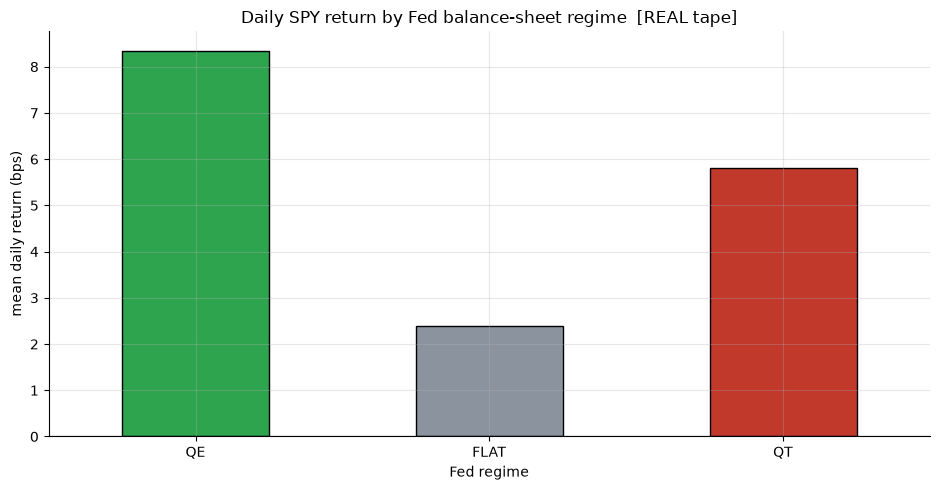

,n,mean_bps,vol_bps,sharpe_ann,tstat
QE,1536.0,8.35,122.69,1.08,3.09
FLAT,5391.0,2.40,119.59,0.32,1.75
QT,1462.0,5.81,101.66,0.91,2.35


In [3]:
# Average daily return by regime, in basis points (1 bp = 0.01%).
rm = st.regime_means(bars)
print(f"[tape: {TAPE}]")
ax = rm['mean_bps'].plot(kind='bar', color=[REG_COL[i] for i in rm.index],
                         edgecolor='black')
ax.axhline(0, color='black', lw=.8)
ax.set_ylabel('mean daily return (bps)'); ax.set_xlabel('Fed regime')
ax.set_title(f'Daily SPY return by Fed balance-sheet regime  [{TAPE} tape]')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()
rm.round(2)


## 4 · The teardown — let's actually look

On the real tape the buckets come out: **QE +8.35 bps/day**, **QT +5.81 bps/day**, FLAT +2.4 bps/day. Read that twice. Stocks went up in QE — *and they went up in QT too*. The thing the slogan says should have been a headwind (the Fed shrinking its balance sheet) coincided with a perfectly healthy bull market.

The gap that the whole idea rests on — **QE minus QT** — is just **+2.54 bps/day**, and once you put an honest error bar on it the range runs from **-4.1** to **+9.15** bps. It straddles zero. Translation: we cannot tell QE and QT apart.

In [4]:
# The decisive contrast: QE minus QT, with an honest bootstrap error bar.
ci = st.diff_block_bootstrap_ci(bars, a='QE', b='QT', n_boot=2000, seed=317)
print(f"[tape: {TAPE}]")
print(f"QE - QT  = {ci['diff_bps']:+.2f} bps/day")
print(f"95% CI   = [{ci['ci_lo']:+.2f}, {ci['ci_hi']:+.2f}]   (straddling 0 = noise)")
print(f"bootstrap p = {ci['p_boot']:.3f}")


[tape: REAL]
QE - QT  = +2.54 bps/day
95% CI   = [-4.05, +9.03]   (straddling 0 = noise)
bootstrap p = 0.471


## 5 · The verdict

- **Signal — NONE.** The QE-vs-QT gap is indistinguishable from zero. Stocks rose in both regimes.
- **Tradability — MIRAGE.** A rule that goes to cash (or short) in QT *underperforms* just buying and holding — see below.
- **'Don't fight the Fed'? — BUSTED.** Fighting the Fed when it tightened would have cost you money.

## 6 · Could you actually trade it?

Take the slogan literally: long stocks in QE and the quiet periods, **cash in QT** (or the braver version, **short in QT**). Race it against simply buying and holding SPY the whole time.

In [5]:
# The literal 'fight the Fed in QT' rule vs buy-and-hold.
import numpy as np
rows = []
for label, short in [('cash in QT', False), ('short in QT', True)]:
    r = st.race(bars, short_qt=short, cost_bps=5.0)
    rows.append({'rule': label,
                 'ann return %': round(r['timing_net']['ann_ret']*100, 2),
                 'Sharpe': round(r['timing_net']['sharpe'], 3)})
bh = st.race(bars, short_qt=False, cost_bps=5.0)['buy_hold']
rows.append({'rule': 'buy & hold', 'ann return %': round(bh['ann_ret']*100, 2),
             'Sharpe': round(bh['sharpe'], 3)})
print(f"[tape: {TAPE}]")
pd.DataFrame(rows).set_index('rule')


[tape: REAL]


,ann return %,Sharpe
rule,,
cash in QT,8.05,0.446
short in QT,5.33,0.279
buy & hold,10.83,0.552


On the real tape buy-and-hold returns **+10.83%/yr** at Sharpe 0.552. Sitting in cash during QT drops you to **+8.05%/yr**; *shorting* during QT — literally fighting the Fed — nearly halves you to **+5.33%/yr**. The rule doesn't just fail to add value; it actively destroys it. (Costs barely matter — the rule trades a fraction of a time per year.)

## 7 · Going further 🚪

So why does the overlay chart look so convincing? Because the Fed **eases hardest into crashes** — QE1 launched in the 2008 wreckage, COVID QE in the March-2020 crater — and stocks then rebound off the bottom. The eye reads 'QE → stocks up'; the truth is 'crash → Fed eases *and* stocks bounce'. That's the only contrast with any signal here (QE beats the *quiet* periods, barely), and it's reverse causation, not a tradable edge.

Forks worth a PR: swap our announced-direction table for the actual weekly `WALCL` dollar change once FRED is reachable; test the *net liquidity* version (WALCL − TGA − reverse repo) that the liquidity crowd actually quotes; or condition on the **rate of change** of the balance sheet rather than its sign.